In [1]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt

In [341]:
annotate_path = '../data/annotation_v2/annotate_boxes/id_47_value_301_107.jpg'
orginal_path = '../data/annotation_v2/annotate_crop/id_47_value_301_107.jpg'

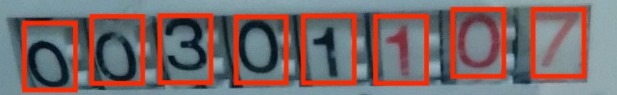

In [342]:
img = Image.open(annotate_path)
img

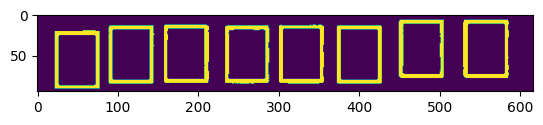

In [343]:
import numpy as np
image = cv2.imread(annotate_path)

# Convert image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define lower and upper bounds of red color in HSV color space
lower_red = np.array([0, 150, 150])
upper_red = np.array([15, 255, 255])
mask1 = cv2.inRange(hsv, lower_red, upper_red)

lower_red = np.array([170, 150, 150])
upper_red = np.array([180, 255, 255])
mask2 = cv2.inRange(hsv, lower_red, upper_red)

# Combine masks
mask = cv2.bitwise_or(mask1, mask2)

# Apply the mask to the original image
#mask = cv2.bitwise_and(image, image, mask=mask1)
plt.imshow(mask)
plt.show()

number of bounding boxes:  8


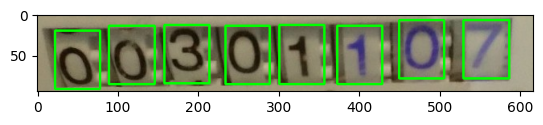

In [344]:
# Find contours
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

x = []
y = []
w = []
h = []
check = 0
if len(contours) > 0:
    for i in range(len(contours)):
        x1, y1, w1, h1 = cv2.boundingRect(contours[i])
        if cv2.contourArea(contours[i]) > 200:
            x.append(x1)
            y.append(y1)
            w.append(w1)
            h.append(h1)
            check += 1
print("number of bounding boxes: ", check)

image = cv2.imread(orginal_path)

for i in range(len(x)):
    cv2.rectangle(image, (x[i], y[i]), (x[i]+w[i], y[i]+h[i]), color = (0, 255, 0), thickness = 2)
plt.imshow(image)
plt.show()

In [106]:
#rename all the files
# import glob
# import os
# for i, file in enumerate(glob.glob('../data/JPEGImages/*.jpg')):
#     os.rename(file, '../data/JPEGImages/' + str(i) + '.jpg')